
# D1 - Come si compongono le uscite dei grandi comuni?

Primo notebook esplorativo sul lato `uscite/comuni` del progetto SIOPE.

**Perimetro**
- anni: `2021`, `2025`
- livello: 10 comuni con uscite totali piu' alte nel `2025`
- base dati: output `mart multi-year (ora `mart.tables[].years`)` `siope_uscite_comuni_agg_labeled_multi_anno`
- confronto principale: peso di spesa corrente, investimenti e flussi tecnici

**Ipotesi di lettura**
- i titoli `5` e `7` sono trattati come flussi tecnici o poco leggibili per confronti descrittivi
- la lettura strutturale si concentra soprattutto su:
  - `1` = spesa corrente
  - `2` = spesa in conto capitale
- il notebook non pretende di spiegare tutto il lato uscite: serve a capire se il perimetro genera segnali utili quanto il lato entrate


In [1]:

from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

project_root = Path.cwd().resolve().parents[2]
cross_path = project_root / "out" / "data" / "mart" / "siope_uscite_comuni" / "*" / "siope_uscite_comuni_agg_labeled.parquet"
# cross_path now uses glob — exists() not applicable

con = duckdb.connect()


## 1. Top 10 comuni del perimetro 2025

In [2]:

top10_sql = f"""
with totali as (
    select
        denominazione_ente,
        sum(importo_totale_eur) as totale_uscite_eur
    from read_parquet('{cross_path.as_posix()}')
    where anno = 2025
    group by 1
)
select *
from totali
order by totale_uscite_eur desc
limit 10
"""

top10 = con.execute(top10_sql).fetchdf()
top10


,denominazione_ente,totale_uscite_eur
0,ROMA CAPITALE,"7,912,216,920.96"
1,COMUNE DI MILANO,"4,484,047,568.47"
2,COMUNE DI NAPOLI,"1,974,890,842.15"
3,COMUNE DI TORINO,"1,825,035,843.95"
4,COMUNE DI GENOVA,"1,632,103,818.64"
5,COMUNE DI CATANIA,"1,243,422,297.36"
6,COMUNE DI FIRENZE,"1,195,937,594.82"
7,COMUNE DI BOLOGNA,"1,190,197,904.47"
8,COMUNE DI VENEZIA,"1,093,939,112.17"
9,COMUNE DI PALERMO,"907,282,966.57"


## 2. Costruzione di una lettura per titoli

In [3]:

base_sql = f"""
with top10 as (
    {top10_sql}
), base as (
    select
        denominazione_ente,
        anno,
        split_part(codice_voce, '.', 1) as titolo,
        sum(importo_totale_eur) as importo_eur
    from read_parquet('{cross_path.as_posix()}')
    where anno in (2021, 2025)
      and denominazione_ente in (select denominazione_ente from top10)
    group by 1, 2, 3
)
select
    denominazione_ente,
    anno,
    titolo,
    case titolo
        when '1' then 'Spesa corrente'
        when '2' then 'Spesa in conto capitale'
        when '3' then 'Incremento attivita finanziarie'
        when '4' then 'Rimborso prestiti'
        when '5' then 'Chiusura anticipazioni'
        when '7' then 'Partite di giro'
        else 'Altro/tecnico'
    end as titolo_label,
    importo_eur
from base
"""

base = con.execute(base_sql).fetchdf()
base.head()


,denominazione_ente,anno,titolo,titolo_label,importo_eur
0,COMUNE DI BOLOGNA,2021,0,Altro/tecnico,0.00
1,COMUNE DI GENOVA,2021,7,Partite di giro,"117,222,558.39"
2,COMUNE DI PALERMO,2021,0,Altro/tecnico,0.00
3,COMUNE DI FIRENZE,2021,0,Altro/tecnico,0.00
4,COMUNE DI CATANIA,2025,7,Partite di giro,"675,978,121.60"


## 3. Quanto pesano i flussi tecnici?

In [4]:

tech_sql = f"""
with base as (
    {base_sql}
)
select
    denominazione_ente,
    anno,
    round(100.0 * sum(case when titolo in ('5', '7') then importo_eur else 0 end) / sum(importo_eur), 2) as quota_tecnica_pct,
    round(100.0 * sum(case when titolo = '1' then importo_eur else 0 end) / nullif(sum(case when titolo not in ('5', '7') then importo_eur else 0 end), 0), 2) as quota_corrente_non_tecnica_pct,
    round(100.0 * sum(case when titolo = '2' then importo_eur else 0 end) / nullif(sum(case when titolo not in ('5', '7') then importo_eur else 0 end), 0), 2) as quota_capitale_non_tecnica_pct
from base
group by 1, 2
order by denominazione_ente, anno
"""

tech = con.execute(tech_sql).fetchdf()
tech_pivot = tech.pivot(index='denominazione_ente', columns='anno', values='quota_tecnica_pct').reset_index()
tech_pivot.columns = ['denominazione_ente', 'quota_tecnica_2021_pct', 'quota_tecnica_2025_pct']
tech_pivot['delta_tecnica_pp'] = tech_pivot['quota_tecnica_2025_pct'] - tech_pivot['quota_tecnica_2021_pct']
tech_pivot.sort_values('quota_tecnica_2025_pct', ascending=False)


,denominazione_ente,quota_tecnica_2021_pct,quota_tecnica_2025_pct,delta_tecnica_pp
1,COMUNE DI CATANIA,56.49,54.36,-2.13
3,COMUNE DI GENOVA,10.34,24.52,14.18
8,COMUNE DI VENEZIA,16.46,13.59,-2.87
5,COMUNE DI NAPOLI,61.07,13.56,-47.51
6,COMUNE DI PALERMO,56.92,11.28,-45.64
9,ROMA CAPITALE,20.10,11.12,-8.98
2,COMUNE DI FIRENZE,34.35,10.69,-23.66
7,COMUNE DI TORINO,53.31,9.89,-43.42
0,COMUNE DI BOLOGNA,12.04,9.41,-2.63
4,COMUNE DI MILANO,9.28,8.87,-0.41


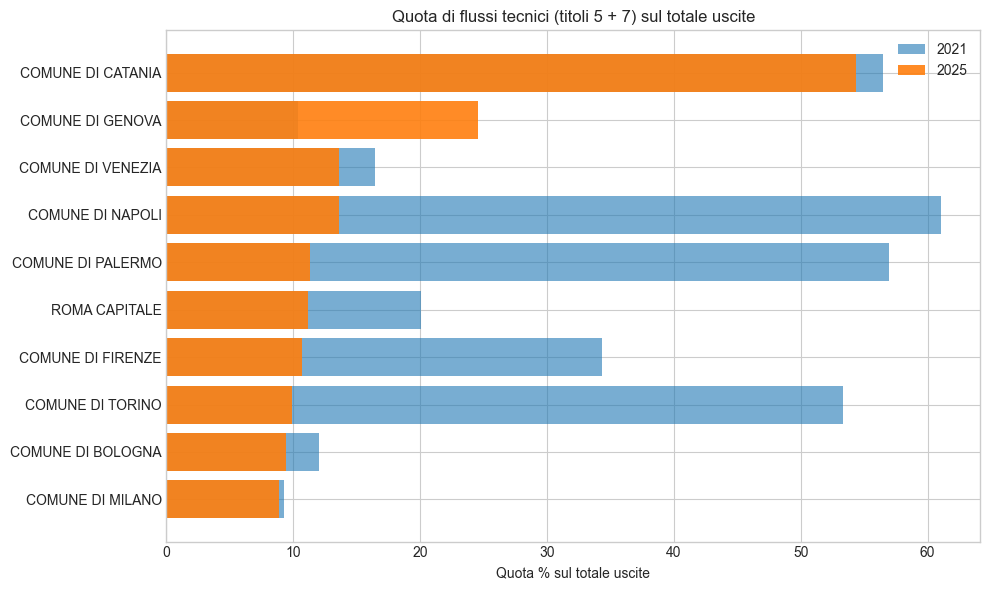

In [5]:

plot_df = tech_pivot.sort_values('quota_tecnica_2025_pct', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df['denominazione_ente'], plot_df['quota_tecnica_2021_pct'], label='2021', alpha=0.6)
ax.barh(plot_df['denominazione_ente'], plot_df['quota_tecnica_2025_pct'], label='2025', alpha=0.9)
ax.set_title('Quota di flussi tecnici (titoli 5 + 7) sul totale uscite')
ax.set_xlabel('Quota % sul totale uscite')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Corrente vs investimenti, al netto dei flussi tecnici

La composizione del secondo grafico non somma a `100%`: nel denominatore restano anche i titoli `3` e `4`, che qui non vengono mostrati per tenere il confronto leggibile.

In [6]:

struct_sql = f"""
with base as (
    {base_sql}
)
select
    denominazione_ente,
    anno,
    round(100.0 * sum(case when titolo = '1' then importo_eur else 0 end) / nullif(sum(case when titolo not in ('5', '7') then importo_eur else 0 end), 0), 2) as quota_corrente_non_tecnica_pct,
    round(100.0 * sum(case when titolo = '2' then importo_eur else 0 end) / nullif(sum(case when titolo not in ('5', '7') then importo_eur else 0 end), 0), 2) as quota_capitale_non_tecnica_pct
from base
group by 1, 2
order by denominazione_ente, anno
"""

struct = con.execute(struct_sql).fetchdf()
struct_2025 = struct[struct['anno'] == 2025].sort_values('quota_capitale_non_tecnica_pct', ascending=False)
struct_2025


,denominazione_ente,anno,quota_corrente_non_tecnica_pct,quota_capitale_non_tecnica_pct
1,COMUNE DI BOLOGNA,2025,60.56,38.35
5,COMUNE DI FIRENZE,2025,67.48,27.71
7,COMUNE DI GENOVA,2025,65.85,25.72
17,COMUNE DI VENEZIA,2025,74.31,23.92
3,COMUNE DI CATANIA,2025,76.51,20.11
11,COMUNE DI NAPOLI,2025,71.15,18.95
15,COMUNE DI TORINO,2025,71.59,18.92
9,COMUNE DI MILANO,2025,75.07,15.39
13,COMUNE DI PALERMO,2025,80.56,15.30
19,ROMA CAPITALE,2025,78.30,13.95


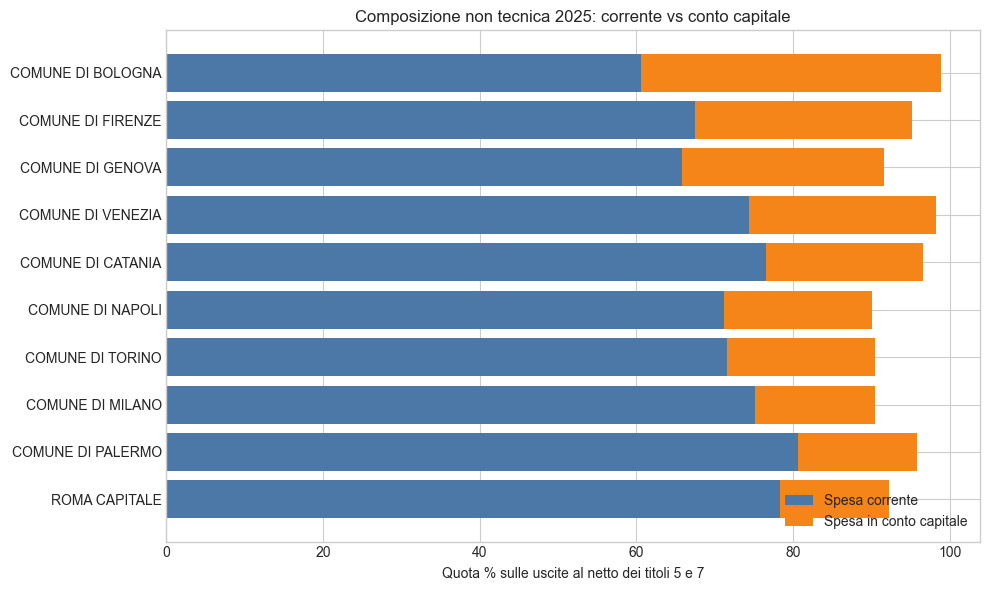

In [7]:

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = struct_2025.sort_values('quota_capitale_non_tecnica_pct', ascending=True)
ax.barh(plot_df['denominazione_ente'], plot_df['quota_corrente_non_tecnica_pct'], label='Spesa corrente', color='#4c78a8')
ax.barh(plot_df['denominazione_ente'], plot_df['quota_capitale_non_tecnica_pct'], left=plot_df['quota_corrente_non_tecnica_pct'], label='Spesa in conto capitale', color='#f58518')
ax.set_title('Composizione non tecnica 2025: corrente vs conto capitale')
ax.set_xlabel('Quota % sulle uscite al netto dei titoli 5 e 7')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 5. Sintesi operativa

In [8]:
summary = tech.merge(struct, on=['denominazione_ente', 'anno'], suffixes=('_tech', '_struct'))
summary_2025 = summary[summary['anno'] == 2025].sort_values('quota_tecnica_pct', ascending=False)
summary_2025[[
    'denominazione_ente',
    'quota_tecnica_pct',
    'quota_corrente_non_tecnica_pct_struct',
    'quota_capitale_non_tecnica_pct_struct'
]]


,denominazione_ente,quota_tecnica_pct,quota_corrente_non_tecnica_pct_struct,quota_capitale_non_tecnica_pct_struct
3,COMUNE DI CATANIA,54.36,76.51,20.11
7,COMUNE DI GENOVA,24.52,65.85,25.72
17,COMUNE DI VENEZIA,13.59,74.31,23.92
11,COMUNE DI NAPOLI,13.56,71.15,18.95
13,COMUNE DI PALERMO,11.28,80.56,15.30
19,ROMA CAPITALE,11.12,78.30,13.95
5,COMUNE DI FIRENZE,10.69,67.48,27.71
15,COMUNE DI TORINO,9.89,71.59,18.92
1,COMUNE DI BOLOGNA,9.41,60.56,38.35
9,COMUNE DI MILANO,8.87,75.07,15.39



### Lettura iniziale

- il lato `uscite` produce gia' un segnale leggibile: nei grandi comuni i titoli tecnici (`5` + `7`) possono distorcere molto il totale, ma non in modo uniforme
- nel `2025` **Catania** resta il caso piu' tecnico del gruppo, con una quota ancora sopra il `50%`
- **Napoli**, **Torino**, **Palermo** e **Firenze** mostrano invece un forte ridimensionamento della componente tecnica rispetto al `2021`
- al netto dei flussi tecnici, nel `2025` la spesa corrente resta dominante ovunque, ma la quota di conto capitale cresce in modo visibile in comuni come **Bologna**, **Firenze**, **Genova** e **Venezia**
- come primo notebook, il perimetro regge: il prossimo passo sensato e' capire se questi segnali meritano un follow-up su poche voci di spesa oppure una lettura per funzioni/missioni esterne a SIOPE
